<a href="https://www.kaggle.com/code/eltayebwadidi/logistic-regression-from-scratch?scriptVersionId=310745966" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np

class LogisticRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = [] # قائمة لحفظ الأخطاء

        for _ in range(self.iterations):
            model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(model)

            # حساب الـ Log Loss (المعادلة الرياضية للخطأ في التصنيف)
            # بنضيف epsilon صغير عشان نتفادى الـ log(0)
            epsilon = 1e-15
            y_predicted = np.clip(y_predicted, epsilon, 1 - epsilon)
            loss = -np.mean(y * np.log(y_predicted) + (1 - y) * np.log(1 - y_predicted))
            self.loss_history.append(loss)

            # تحديث الأوزان
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            # 4. Update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(model)
        # تحويل الاحتمالات لـ 0 أو 1
        return [1 if i > 0.5 else 0 for i in y_predicted]

In [3]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

# تحميل البيانات
data = datasets.load_breast_cancer()
X, y = data.data, data.target

# تقسيم البيانات (تدريب واختبار)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

In [4]:
# إنشاء نسخة من الموديل
clf = LogisticRegression(learning_rate=0.0001, iterations=5000)

# التدريب
clf.fit(X_train, y_train)

# التوقع على بيانات الاختبار
predictions = clf.predict(X_test)

In [5]:
def accuracy(y_true, y_pred):
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    return accuracy

print(f"Logistic Regression Accuracy: {accuracy(y_test, predictions) * 100:.2f}%")

Logistic Regression Accuracy: 92.98%


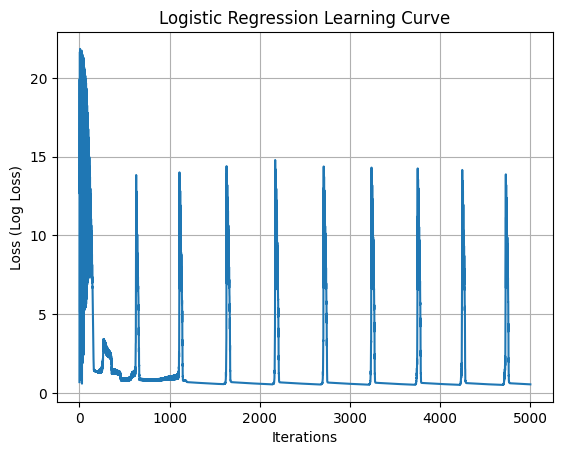

In [6]:
import matplotlib.pyplot as plt

plt.plot(clf.loss_history)
plt.title("Logistic Regression Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss (Log Loss)")
plt.grid(True)
plt.show()

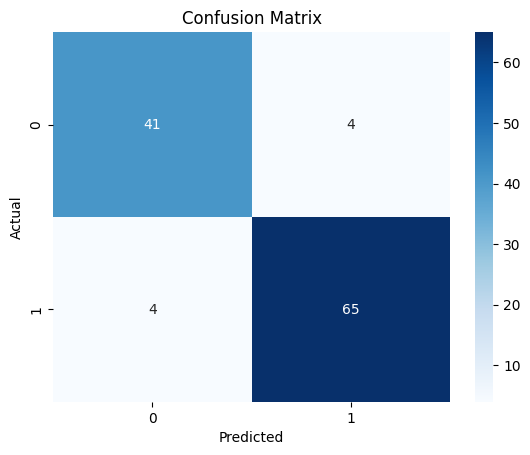

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()